## 01. SVM - SVC

**SVM**: 분류 문제에서 **클래스를 나누는 경계**를 찾는 모델.
**SVC**: scikit-learn에서 사용하는 **SVM 분류 모델** 이름.
**SVR**: scikit-learn에서 사용하는 **SVM 회귀 모델** 이름.

---

### 01-01. SVM, SVC란?

> SVM: 두 클래스 사이에 선을 긋되, 데이터와 최대한 멀리 떨어진 안정적인 선을 찾는 모델.


> SVC: SVM을 이용해 데이터를 클래스로 분류하는 scikit-learn의 분류 모델

### 01-02. 왜 배우는가?

**결정 경계 관점을 이해하기 좋음**
- 분류 모델이 데이터를 어떻게 나누는지 그림으로 설명하기 좋음.
- 이후 분류 평가지표, 과대적합, 하이퍼파라미터 튜닝과 연결하기 좋음.

**마진이라는 새로운 기준을 배울 수 있음**
- 단순히 훈련 데이터를 많이 맞히는 것이 목표가 아님.
- 두 클래스 사이의 여유 공간이 넓은 경계를 찾는 것이 핵심임.

**스케일링 필요성을 다시 설명하기 좋음**
- SVM은 거리와 마진을 중요하게 봄.
- feature 숫자 범위가 다르면 큰 값의 feature가 경계에 더 큰 영향을 줄 수 있음.

**커널 기법으로 비선형 분류를 설명할 수 있음**
- 직선으로 나누기 어려운 데이터도 `rbf` 같은 커널로 다룰 수 있음.

### 01-03. 어디서 사용하는가?

**데이터 수가 아주 크지 않고 feature 수가 적당한 분류 문제**
- 의료 수치 데이터 분류
- 생물학 feature 분류
- 정상/불량 분류

**경계가 중요한 문제**
- 두 클래스를 나누는 기준을 시각적으로 설명하고 싶은 경우
- 선형 경계와 비선형 경계를 비교하고 싶은 경우

**텍스트나 이미지에서 추출한 feature를 분류하는 문제**
- 문서 분류
- 이미지 feature 분류
- 임베딩 벡터 기반 분류
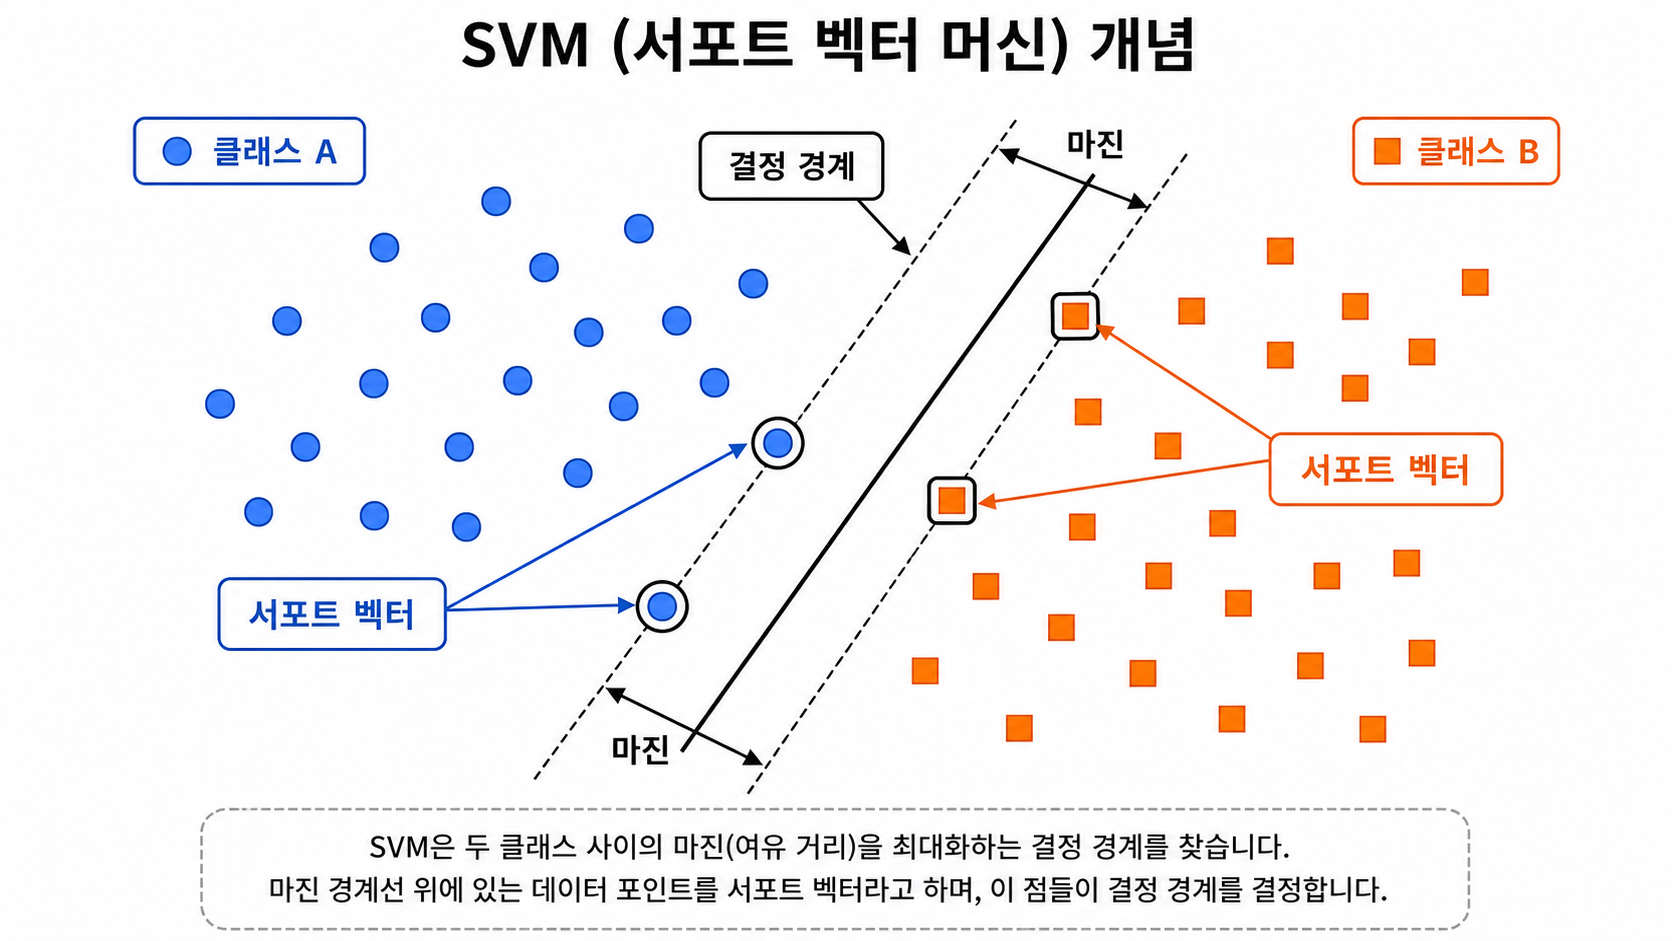
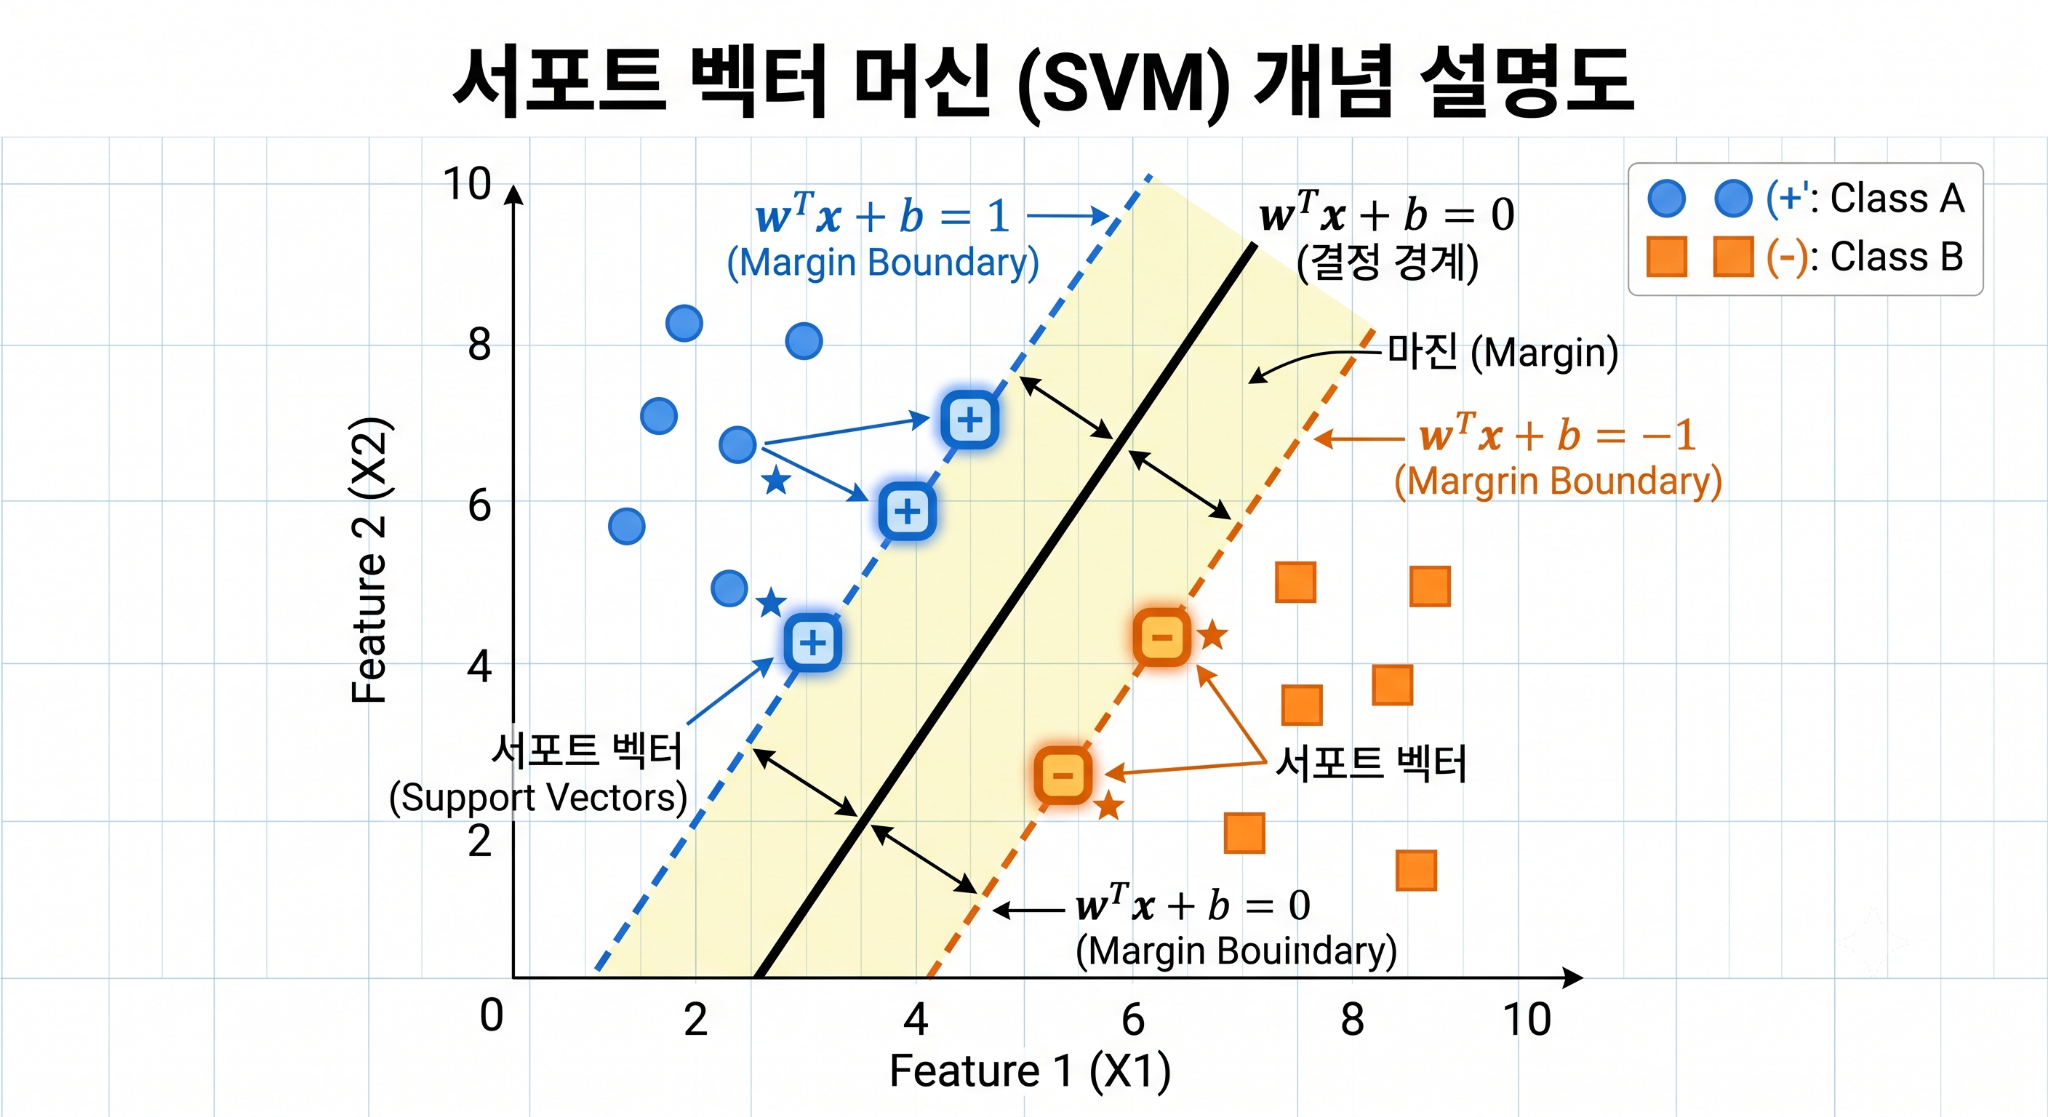


### 01-04. 핵심 용어 정리

**결정 경계 Decision Boundary**
- 클래스를 나누는 기준선 또는 기준면임.
- feature가 2개면 선으로 보이고, feature가 3개면 면처럼 보임.

**초평면 Hyperplane**
- 고차원 feature 공간에서의 결정 경계임.
- feature가 2개일 때는 선, 3개일 때는 면, 그 이상에서는 초평면이라고 부름.
- SVM에서 말하는 결정 경계의 수학적 표현이라고 보면 됨.

**마진 Margin**
- 결정 경계와 가장 가까운 데이터 사이의 거리임.
- 경계 주변의 여유 공간이라고 보면 됨.
- 마진이 넓으면 새 데이터가 조금 흔들려도 비교적 안정적으로 분류할 가능성이 높음.

**서포트 벡터 Support Vector**
- 결정 경계에 가장 가까운 데이터 포인트임.
- SVM의 경계 위치를 결정하는 핵심 샘플임.
- 이 점들이 움직이면 결정 경계도 달라질 수 있음.

**SVC Support Vector Classifier**
- SVM을 이용한 분류 모델임.
- scikit-learn에서는 `from sklearn.svm import SVC`로 사용함.


### 01-05. 결정 경계, 마진, 서포트 벡터 관계
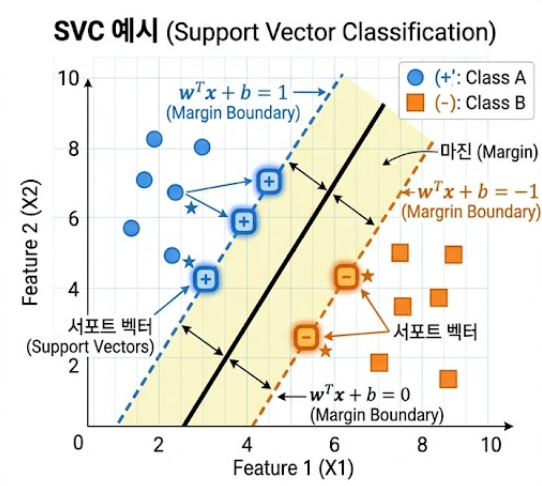

- 가운데 기준선이 **결정 경계**임.
- 결정 경계 양쪽의 여유 공간이 **마진**임.
- 마진에 가장 가까이 닿아 있는 데이터가 **서포트 벡터**임.
- SVM은 여러 가능한 경계 중에서 **마진이 가장 넓은 경계**를 찾으려 함.


### 01-06. 좋은 결정 경계란?

좋은 결정 경계는 단순히 훈련 데이터를 많이 맞히는 선이 아님.
SVM에서 좋은 결정 경계는 **두 클래스 사이를 나누면서, 가장 가까운 데이터와의 거리인 마진을 크게 확보한 경계**.

> **마진이 넓고, 너무 단순하지도 복잡하지도 않은 균형 잡힌 경계**임.

즉, 좋은 경계의 기준은 다음과 같음.

1. 두 클래스를 잘 구분해야 함.


2. 결정 경계가 특정 데이터에 너무 붙어 있지 않아야 함.
    - 새 데이터가 조금만 달라져도 반대 클래스로 예측될 수 있음.
    - 안정적인 경계라고 보기 어려움.


3. 마진이 넓어 새 데이터가 조금 달라져도 예측이 안정적이어야 함.
    - 결정 경계와 가까운 데이터 사이에 여유 공간이 큼.
    - 새 데이터가 조금 흔들려도 같은 클래스로 예측될 가능성이 높음.
    - SVM이 선호하는 좋은 경계에 가까움.


4. 너무 복잡해서 훈련 데이터를 외우는 형태가 아니어야 함.

    **너무 복잡한 경계**
    - 훈련 데이터 하나하나에 지나치게 맞춘 경계임.
    - 학습 데이터에서는 잘 맞지만 새 데이터에서는 성능이 떨어질 수 있음.
    - 과대적합 가능성이 있음.

    **너무 단순한 경계**
    - 데이터의 실제 패턴을 충분히 반영하지 못하는 경계임.
    - 학습 데이터와 새 데이터 모두에서 성능이 낮을 수 있음.
    - 과소적합 가능성이 있음.



### 01-07. 주요 하이퍼파라미터

**`kernel - 비선형 데이터를 고차원 공간으로 변환하여 선형적으로 분리 가능하게 만드는 방법`**
- 결정 경계의 형태를 정하는 설정값임.
- `linear`: 직선 또는 초평면 경계
- `rbf`: 곡선형 경계
- `poly`: 다항식 형태 경계

**`C - 마진 경계를 넘은 데이터를 얼마나 엄격하게 처리할지 정하는 설정값`**
- 오분류를 얼마나 강하게 혼낼지 **벌점**을 정하는 값임.
- `C`가 작으면 오분류를 더 허용하고 경계가 단순해질 수 있음.
- `C`가 크면 오분류를 줄이려 하므로 경계가 복잡해질 수 있음.

**`gamma - RBF 커널에서 한 데이터 포인트가 주변에 영향을 주는 범위`**
- `gamma`가 작으면 넓은 범위에 영향을 주어 부드러운 경계가 만들어짐.
- `gamma`가 크면 가까운 점에만 민감해져 복잡한 경계가 만들어질 수 있음.


### 01-08. 커널을 왜 사용하는가?

**선형 커널 `linear`**
- 직선 또는 초평면으로 데이터를 나눔.
- 해석이 비교적 쉽고 빠름.
- 데이터가 선형적으로 어느 정도 나뉠 때 사용하기 좋음.

**RBF 커널 `rbf`**
- 곡선형 결정 경계를 만들 수 있음.
- 직선으로 나누기 어려운 비선형 데이터에서 자주 사용함.
- 수업에서는 `make_moons` 데이터로 차이를 보여주기 좋음.

**다항 커널 `poly`**
- 다항식 형태의 경계를 만들 수 있음.
- feature 조합에 따른 곡선 패턴을 보고 싶을 때 사용할 수 있음.


### 01-09. 스케일링이 필요한 이유

SVM은 거리와 마진을 기준으로 경계를 찾음.
따라서 feature의 숫자 범위가 다르면 큰 범위의 feature가 결정 경계를 과하게 지배할 수 있음.

예를 들어 다음과 같은 상황을 생각할 수 있음.

```text
feature A 범위: 0 ~ 1
feature B 범위: 0 ~ 1000
```

이 상태에서 거리를 계산하면 feature B가 훨씬 크게 반영됨.
그래서 SVC에서는 보통 `StandardScaler`로 feature를 평균 0, 표준편차 1 기준에 맞춘 뒤 학습함.

## 02. 실습 환경 준비

- `load_iris`: Iris 분류 예제 데이터를 불러오는 함수.
- `StandardScaler`: feature를 평균 0, 표준편차 1 기준으로 맞추는 전처리기.
- `SVC`: SVM 분류 모델.
- `PCA`: 고차원 feature를 2차원으로 줄여 시각화할 때 사용하는 차원축소 기법.
- `DecisionBoundaryDisplay`: 분류 모델의 결정 경계를 시각화하는 도구.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, classification_report

## 03. Iris 데이터 로드

- Iris 데이터는 붓꽃의 꽃받침/꽃잎 길이와 너비로 품종을 분류하는 대표 예제 데이터임.
- target은 `setosa`, `versicolor`, `virginica` 세 개 클래스임.
- SVC가 다중분류에서도 사용할 수 있음을 보여주기 좋음.

In [3]:
# load_iris(as_frame=True): Iris 데이터를 DataFrame 형태로 불러옴.
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()

# target은 숫자로 저장되어 있으므로 수업 화면에서 읽기 쉽게 품종 이름 컬럼을 추가함.
target_name_map = dict(enumerate(iris.target_names))
iris_df['target_name'] = iris_df['target'].map(target_name_map)

display(iris_df.head())
print('데이터 크기:', iris_df.shape)
print('target 분포')
print(iris_df['target_name'].value_counts())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


데이터 크기: (150, 6)
target 분포
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 04. 학습/평가 데이터 분리와 스케일링

- SVM은 거리와 마진을 보는 모델이므로 스케일링이 중요함.
- `train_test_split()`으로 학습 데이터와 평가 데이터를 나눔.
- `StandardScaler`는 학습 데이터에만 `fit_transform()`하고, 평가 데이터에는 `transform()`만 적용함.

In [5]:
svc_X = iris_df[iris.feature_names]
svc_y = iris_df['target']

svc_X_train, svc_X_test, svc_y_train, svc_y_test = train_test_split(
    svc_X,
    svc_y,
    test_size=0.2,
    random_state=42,
    stratify=svc_y # train, test 비율 같게 나누기
)

svc_scaler = StandardScaler()
svc_X_train_scaled = svc_scaler.fit_transform(svc_X_train)
svc_X_test_scaled = svc_scaler.transform(svc_X_test)

print(svc_X_train_scaled.shape, svc_y_train.shape)
print(svc_X_test_scaled.shape, svc_y_test.shape)


(120, 4) (120,)
(30, 4) (30,)


## 05. 선형 SVC 모델 학습

- `kernel='linear'`는 직선 또는 초평면으로 클래스를 나누는 SVC임.
- 분류 모델의 `score()`는 기본적으로 accuracy를 반환함.
- 학습셋과 평가셋 accuracy를 함께 비교해 과대적합 여부를 간단히 확인함.

In [8]:
# kernel : 결정 경계 모양
# kernel='linear -> 선형 결정 경계 이용
# C = 1.0: 마진 경계를 넘어선 데이터 (== 오분류 데이터)에 대한 벌점
# (기본값 1.0)
linear_svc = SVC(
    kernel='linear',
    C=1.0,
    random_state=42,
)
linear_svc.fit(svc_X_train_scaled, svc_y_train)

# 평가
print("학습셋(accuracy): ", linear_svc.score(svc_X_train_scaled, svc_y_train))
print("평가셋(accuracy): ", linear_svc.score(svc_X_test_scaled, svc_y_test))

# 예측
svc_y_pred = linear_svc.predict(svc_X_test_scaled)
print()
print(classification_report(
    svc_y_test,
    svc_y_pred,
    target_names=iris.target_names,
))

학습셋(accuracy):  0.975
평가셋(accuracy):  1.0

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 06. C 값 변화 비교

- `C`는 오분류를 얼마나 강하게 벌점으로 줄지 정하는 값임.
- `C`가 작으면 경계가 단순해질 수 있고, `C`가 크면 학습 데이터를 더 세밀하게 맞추려 할 수 있음.
- 같은 데이터에서 `C` 후보를 비교하면 하이퍼파라미터가 성능에 주는 영향을 설명하기 좋음.

In [18]:
c_results = []

for c_value in [0.1, 1, 10, 100]:
    model = SVC(kernel='linear', C=c_value, random_state=42)
    model.fit(svc_X_train_scaled, svc_y_train)

    c_results.append({
        'C': c_value,
        'train_accuracy': model.score(svc_X_train_scaled, svc_y_train),
        'test_accuracy': model.score(svc_X_test_scaled, svc_y_test),
        'support_vector_count': len(model.support_),
    })

c_results_df = pd.DataFrame(c_results)
c_results_df

# C가 증가할수록 Support_vector가 줄어드는 경향이 있음 -> 마진경계가 넓게 생성된다

,C,train_accuracy,test_accuracy,support_vector_count
0,0.1,0.975000,0.933333,56
1,1.0,0.975000,1.000000,23
2,10.0,0.975000,0.966667,14
3,100.0,0.983333,1.000000,11


## 07. PCA로 2차원 시각화용 데이터 만들기
> PCA란?
> Principal Component Analysis(주성분 분석) 약자로
> 여러 feature를 정보 손실을 최대한 줄이면서 더 적은 수의 feature로 압축하는 방법이다.

- Iris 데이터는 feature가 4개라 결정 경계를 바로 2차원 그래프로 그리기 어려움.
    - 그래프를 그릴 때 feature를 이용해서 축을 표현하기 때문!
    - feature가 4개 == 축이 4개 == 4차원(그릴 수 없음)
- PCA로 4개 feature를 2개 주성분으로 줄여 시각화용 데이터를 만듦.
- 이 PCA 결과는 시각화와 직관적 설명을 위한 것이며, 실제 성능 평가는 앞의 4개 feature 모델을 함께 봐야 함.

In [19]:
# iris 데이터의 feature == 4개 -> 그래프 작성시 푹이 4개 필요(그릴수 없으므로 PCA 이용)
svc_pca = PCA(n_components=2)

svc_X_train_pca = svc_pca.fit_transform(svc_X_train_scaled)
svc_X_test_pca = svc_pca.fit_transform(svc_X_test_scaled)

print("학습 전 shape: ", svc_X_train_scaled.shape)
print("학습 후 shape: ", svc_X_train_pca.shape)

# [설명 분산 비율]
# 새로 만든 feature에 원본 데이터 정보량을 얼마나 담고 있는지의 비율
print("설명 분산 비율: ", svc_pca.explained_variance_ratio_ )
print("누적 설명 분산 비율: ", svc_pca.explained_variance_ratio_.sum())

학습 전 shape:  (120, 4)
학습 후 shape:  (120, 2)
설명 분산 비율:  [0.78186207 0.18417746]
누적 설명 분산 비율:  0.9660395249593802


## 08. PCA 데이터에서 선형 결정 경계 시각화

- `DecisionBoundaryDisplay`는 2차원 feature에서 모델의 결정 영역을 시각화함.
- 배경색은 모델이 예측한 클래스 영역이고, 점은 실제 학습 데이터임.
- 실제 수업에서는 “경계 근처의 점들이 모델 판단을 어렵게 만든다”는 관점으로 설명함.

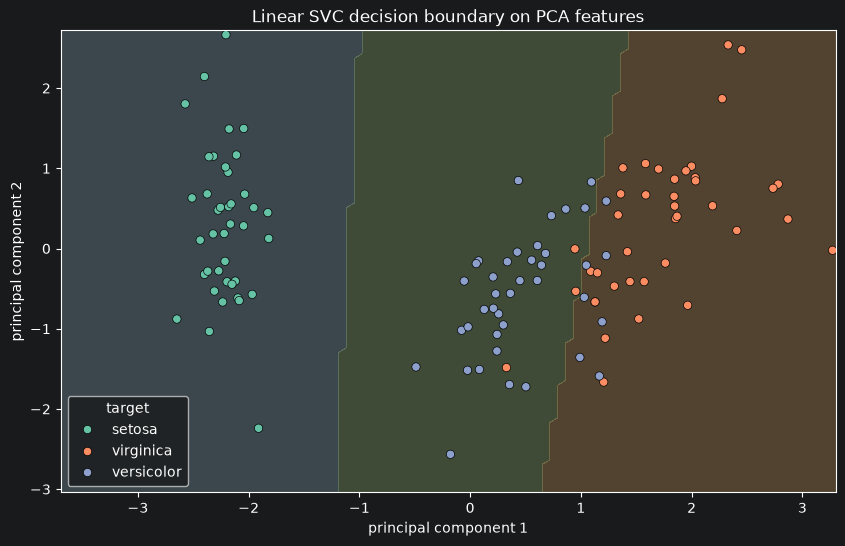

학습셋:  0.9166666666666666
평가셋:  0.9333333333333333


In [27]:
pca_linear_svc = SVC(kernel='linear', C=1.0, random_state=42)
pca_linear_svc.fit(svc_X_train_pca, svc_y_train)

plt.figure(figsize=(10, 6))

ax = plt.gca() # 현재 axes를 얻어오기. 없으면 생성

DecisionBoundaryDisplay.from_estimator(
    pca_linear_svc,
    svc_X_test_pca,
    response_method='predict',
    plot_method='contourf',
    alpha=0.25,
    multiclass_colors=['#a6cee3', '#b2df8a', '#fdbf6f'],
    ax=ax
)

sns.scatterplot(
    x=svc_X_train_pca[:, 0],
    y=svc_X_train_pca[:, 1],
    hue=[iris.target_names[i] for i in svc_y_train],
    palette='Set2',
    edgecolor='black',
    ax=ax
)

plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.title('Linear SVC decision boundary on PCA features')
plt.legend(title='target')


plt.show()

print("학습셋: ", pca_linear_svc.score(svc_X_train_pca, svc_y_train))
print("평가셋: ", pca_linear_svc.score(svc_X_test_pca, svc_y_test))

## 09. 비선형 데이터와 RBF(Radial Basis Function) 커널

- 선형 커널은 직선 경계로 나누기 어려운 데이터에서 한계가 있을 수 있음.
- RBF 커널은 데이터 포인트 사이의 거리 기반 유사도를 사용해 비선형 경계를 만들 수 있음.
- `make_moons` 예제는 비선형 경계가 필요한 상황을 보여주기 좋음.

In [34]:
moon_X, moon_y = make_moons(n_samples=300, noise=0.25, random_state=42)

moon_X_train, moon_X_test, moon_y_train, moon_y_test = train_test_split(
    moon_X,
    moon_y,
    test_size=0.25,
    random_state=42,
    stratify=moon_y
)

moon_scaler = StandardScaler()
moon_X_train_scaled = moon_scaler.fit_transform(moon_X_train)
moon_X_test_scaled = moon_scaler.transform(moon_X_test)

In [48]:
moon_models = {
    'linear': SVC(
        kernel='linear',
        C=1.0,
        random_state=42,),
    'rbf': SVC(
        kernel='rbf',
        C=1.0,
        random_state=42,
        gamma=1.0,)
}

# 평가 -> 비선형 데이터에서 rbf 가 더 정확한 값을 나타냄
for name, model in moon_models.items():
    model.fit(moon_X_train_scaled, moon_y_train)

    print(f'{name} model accuracy: ', model.score(moon_X_test_scaled, moon_y_test))

linear model accuracy:  0.8533333333333334
rbf model accuracy:  0.8933333333333333


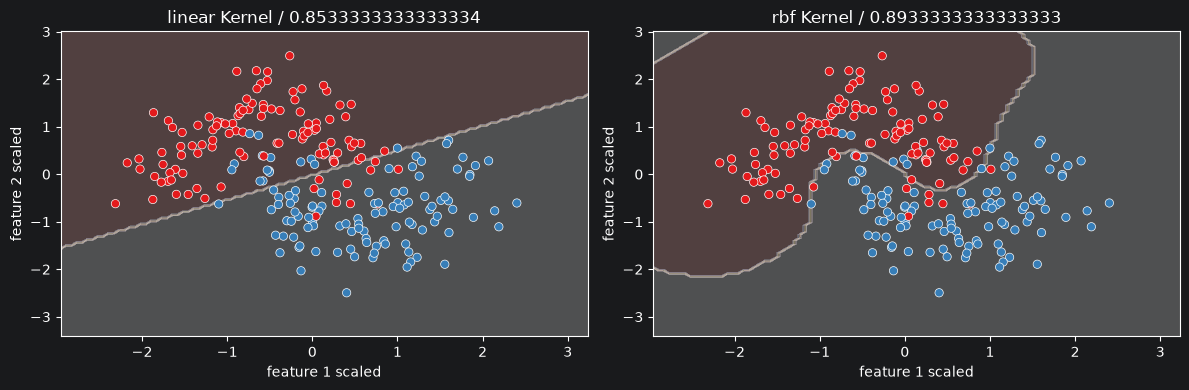

In [49]:
# 시각화
fig, axes = plt.subplots(1,2,figsize=(12, 4))

for ax,(name, model) in zip(axes, moon_models.items()):

    DecisionBoundaryDisplay.from_estimator(
        model,
        moon_X_test_scaled,
        response_method='predict',
        plot_method='contourf',
        alpha=0.25,
        ax=ax,
        cmap='Pastel1'
    )

    sns.scatterplot(
        x=moon_X_train_scaled[:, 0],
        y=moon_X_train_scaled[:, 1],
        hue=moon_y_train,
        palette='Set1',
        legend=False,
        ax=ax
    )


    ax.set_title(f'{name} Kernel / {model.score(moon_X_test_scaled, moon_y_test)}')
    ax.set_xlabel('feature 1 scaled')
    ax.set_ylabel('feature 2 scaled')

plt.tight_layout()
plt.show()


## 10. gamma 값 변화 비교

- `gamma`는 RBF 커널에서 한 데이터 포인트가 주변에 미치는 영향 범위임.
- `gamma`가 너무 작으면 경계가 지나치게 단순해져 과소적합될 수 있음.
- `gamma`가 너무 크면 경계가 훈련 데이터에 지나치게 민감해져 과대적합될 수 있음.

In [40]:
gamma_results = []

for gamma_value in [0.1, 1, 10, 100]:
    model = SVC(kernel='rbf', C=1.0, gamma=gamma_value, random_state=42)
    model.fit(moon_X_train_scaled, moon_y_train)

    gamma_results.append({
        'gamma': gamma_value,
        'train_accuracy': model.score(moon_X_train_scaled, moon_y_train),
        'test_accuracy': model.score(moon_X_test_scaled, moon_y_test),
        'support_vector_count': len(model.support_)
    })

gamma_result_df = pd.DataFrame(gamma_results)
display(gamma_result_df)

,gamma,train_accuracy,test_accuracy,support_vector_count
0,0.1,0.871111,0.840000,85
1,1.0,0.915556,0.893333,69
2,10.0,0.960000,0.920000,132
3,100.0,0.986667,0.866667,216
